# AICE 모의고사 3회 - 대출 상환 예측

## 문제 시나리오

대출 신청자의 개인 정보 및 금융 데이터를 분석 및 전처리한 후 머신러닝과 딥러닝으로 대출 상환 가능성 점수를 예측하고 결과를 분석하세요. (상환 가능성 점수는 0-100 사이의 숫자 값)

## 3-1 | 라이브러리 임포트 및 데이터 로딩

### 【 문제 】

- scikit-learn을 sk로, pandas를 pd로 임포트하세요.
- loan_applicants.json을 읽어 df_applicants에 저장하세요.
- financial_history.csv를 읽어 df_history에 저장하세요.

In [32]:
import sklearn as sk
import pandas as pd

df_applicants = pd.read_json('./loan_applicants.json')
df_history = pd.read_csv('./financial_history.csv')

## 3-2 | 데이터 병합 및 초기 탐색

### 【 문제 】

- ApplicantID 기준으로 inner join하여 df 생성하세요.
- df.info( )와 df.head( )로 데이터 기본 구조를 확인하세요.

In [33]:
df = pd.merge(df_applicants, df_history, on='ApplicantID', how='inner')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ApplicantID           117 non-null    int64  
 1   Age                   117 non-null    int64  
 2   Income_USD            117 non-null    int64  
 3   CreditScore           112 non-null    float64
 4   LoanAmount_USD        117 non-null    int64  
 5   LoanTerm_months       117 non-null    int64  
 6   EmploymentType        117 non-null    object 
 7   EducationLevel        117 non-null    object 
 8   NumCreditCards        117 non-null    int64  
 9   DebtToIncomeRatio     117 non-null    float64
 10  PreviousLoanDefaults  117 non-null    int64  
 11  AnnualIncome          111 non-null    float64
 12  RepaymentScore        117 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 12.0+ KB


In [34]:
df.head()

,ApplicantID,Age,Income_USD,CreditScore,LoanAmount_USD,LoanTerm_months,EmploymentType,EducationLevel,NumCreditCards,DebtToIncomeRatio,PreviousLoanDefaults,AnnualIncome,RepaymentScore
0,1,36,161932,406.0,81820,24,Salaried,Masters,1,0.16,3,160462.0,71
1,2,45,117498,672.0,49131,36,Salaried,Bachelors,1,0.19,2,115058.0,78
2,3,51,89735,685.0,10311,48,Salaried,HighSchool,7,0.39,3,90203.0,67
3,4,43,105305,NaN,98016,12,Self-Employed,Masters,2,0.50,1,107246.0,67
4,5,49,142537,489.0,89654,36,Self-Employed,PhD,4,0.19,2,145083.0,62


## 3-3 | 범주형 변수 로트 시각화 및 데이터 경제

### 【 문제 】

- EmploymentType 분포를 countplot으로 시각화하세요.
- EmploymentType 값 중 'Unemployed'를 가진 행을 삭제하세요.
- 삭제된 행 개수를 답안03에 저장하세요.

<Axes: xlabel='EmploymentType', ylabel='count'>

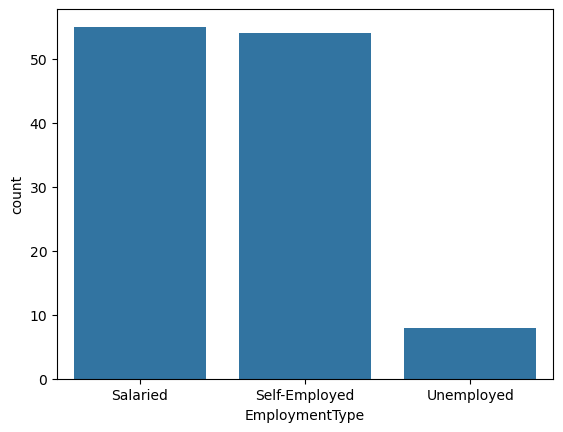

In [35]:
import seaborn as sns

sns.countplot(data=df, x='EmploymentType')

8


<Axes: xlabel='EmploymentType', ylabel='count'>

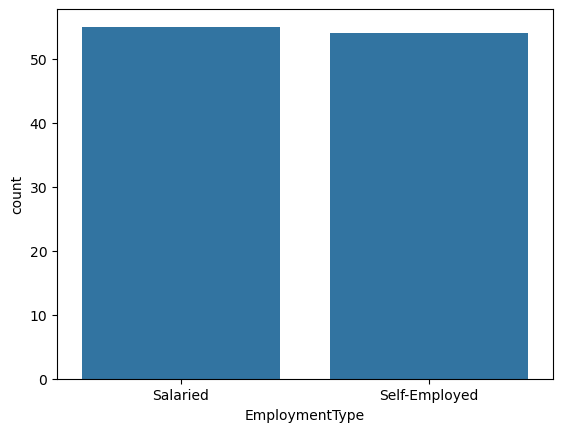

In [36]:
initial_rows = df['EmploymentType'].shape[0]
unemployed_rows = df[df['EmploymentType'] != 'Unemployed'].copy().shape[0]
답안03 = initial_rows - unemployed_rows
print(답안03)

df = df[df['EmploymentType'] != 'Unemployed'].copy()

sns.countplot(data=df, x='EmploymentType')

## 3-4 | 수치형 변수 관계 시각화 및 이상치 탐색

### 【 문제 】

- Income_USD와 RepaymentScore의 jointplot을 그리세요.
- Income_USD ≥ 300000을 이상치로 간주하고 개수를 답안04에 저장하세요.


9


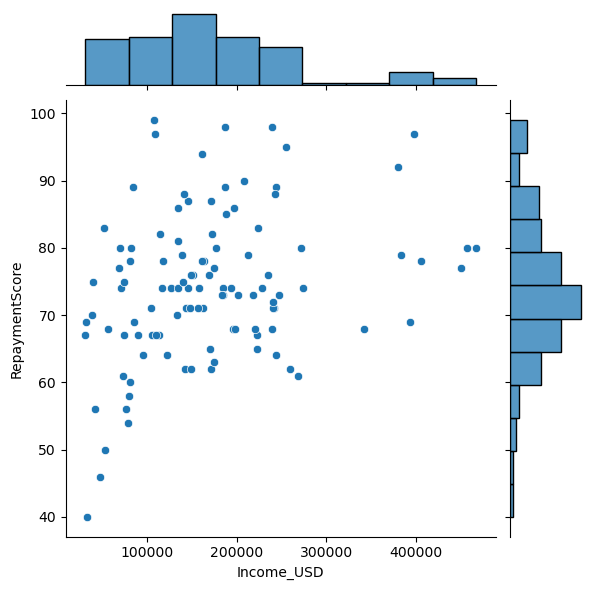

In [37]:
sns.jointplot(data=df, x='Income_USD', y='RepaymentScore')

답안04 = df[df['Income_USD'] >= 300000].shape[0]
print(답안04)

## 3-5 | 이상치 및 불필요 컬럼 처리

### 【 문제 】

- Income_USD ≥ 300000 이상치를 제거하세요.
- ApplicantID 컬럼을 삭제하세요.
- 결과를 df_temp에 저장하세요.

In [38]:
df_temp = df[df['Income_USD'] < 300000].copy()
df_temp = df_temp.drop('ApplicantID', axis=1)
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 116
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   100 non-null    int64  
 1   Income_USD            100 non-null    int64  
 2   CreditScore           96 non-null     float64
 3   LoanAmount_USD        100 non-null    int64  
 4   LoanTerm_months       100 non-null    int64  
 5   EmploymentType        100 non-null    object 
 6   EducationLevel        100 non-null    object 
 7   NumCreditCards        100 non-null    int64  
 8   DebtToIncomeRatio     100 non-null    float64
 9   PreviousLoanDefaults  100 non-null    int64  
 10  AnnualIncome          94 non-null     float64
 11  RepaymentScore        100 non-null    int64  
dtypes: float64(3), int64(7), object(2)
memory usage: 10.2+ KB


## 3-6 | 결측치 처리 및 데이터 타입 변환

### 【 문제 】

- 결측치를 확인하고, AnnualIncome과 CreditScore 컬럼에 있는 결측치를 각 컬럼의 평균값으로 대체하세요.
- 결과를 df_na에 저장하고, 결측치가 대체된 총 개수를 답안06에 저장하세요.


In [40]:
print(f'결측치 확인 :\n{df_temp.isna().sum()}')

답안06 = df_temp['AnnualIncome'].isnull().sum() + df_temp['CreditScore'].isnull().sum()

print(f'\n답안06 : {답안06}')

mean_income = df_temp['AnnualIncome'].mean()
mean_credit_score = df_temp['CreditScore'].mean()

df_temp['AnnualIncome'] = df_temp['AnnualIncome'].fillna(mean_income)
df_temp['CreditScore'] = df_temp['CreditScore'].fillna(mean_credit_score)

print(f'결측치 확인 :\n{df_temp.isna().sum()}')

df_na = df_temp.copy()

결측치 확인 :
Age                     0
Income_USD              0
CreditScore             4
LoanAmount_USD          0
LoanTerm_months         0
EmploymentType          0
EducationLevel          0
NumCreditCards          0
DebtToIncomeRatio       0
PreviousLoanDefaults    0
AnnualIncome            6
RepaymentScore          0
dtype: int64

답안06 : 10
결측치 확인 :
Age                     0
Income_USD              0
CreditScore             0
LoanAmount_USD          0
LoanTerm_months         0
EmploymentType          0
EducationLevel          0
NumCreditCards          0
DebtToIncomeRatio       0
PreviousLoanDefaults    0
AnnualIncome            0
RepaymentScore          0
dtype: int64


## 3-7 | 불필요 컬럼 처리 및 원-핫 인코딩

### 【 문제 】

- EmploymentType, EducationLevel을 원-핫 인코딩하세요.
- 결과를 df_encoded에 저장하세요.

In [42]:
df_encoded = pd.get_dummies(df_na, columns=['EmploymentType', 'EducationLevel'])
df_encoded.head()

,Age,Income_USD,CreditScore,LoanAmount_USD,LoanTerm_months,NumCreditCards,DebtToIncomeRatio,PreviousLoanDefaults,AnnualIncome,RepaymentScore,EmploymentType_Salaried,EmploymentType_Self-Employed,EducationLevel_Bachelors,EducationLevel_HighSchool,EducationLevel_Masters,EducationLevel_PhD
0,36,161932,406.0000,81820,24,1,0.16,3,160462.0,71,True,False,False,False,True,False
1,45,117498,672.0000,49131,36,1,0.19,2,115058.0,78,True,False,True,False,False,False
2,51,89735,685.0000,10311,48,7,0.39,3,90203.0,67,True,False,False,True,False,False
3,43,105305,560.0625,98016,12,2,0.50,1,107246.0,67,False,True,False,False,True,False
4,49,142537,489.0000,89654,36,4,0.19,2,145083.0,62,False,True,False,False,False,True


## 3-8 | 데이터 분리 및 스케일링

### 【 문제 】

- RepaymentScore를 y로, 나머지를 X로 설정하세요.
- train_test_split으로 80:20 분할하고 random_state=42로 설정하세요.
- StandardScaler로 스케일링하세요.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y = df_encoded['RepaymentScore']
X = df_encoded.drop('RepaymentScore', axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train)
X_valid_scaled = ss.fit_transform(X_valid)

## 3-9 | 머신러닝 모델 학습(Linear Regression)

### 【 문제 】

- sklearn.linear_model에서 LinearRegression을 임포트하세요.
- 학습 데이터를 이용해 linreg_model을 학습시키세요.

In [48]:
from sklearn.linear_model import LinearRegression

linreg_model = LinearRegression()
linreg_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 3-10 | 머신러닝 모델 학습(XGBoost Regressor)

### 【 문제 】

- xgboost에서 XGBRegressor를 임포트하세요.
- random_state=42, n_estimators=200, learning_rate=0.1로 설정하세요.
- 학습 데이터를 이용해 xgb_model을 학습시키세요.

In [50]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 3-11 | 모델 성능 평가(MAE, RMSE, R² 계산)

### 【 문제 】

- 학습된 linreg_model과 xgb_model의 검증 데이터 예측 결과를 평가하세요.
- MAE, RMSE, R²를 각각 계산해 출력하세요.

In [51]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

y_pred_lin = linreg_model.predict(X_valid_scaled)
y_pred_xgb = xgb_model.predict(X_valid_scaled)

mae_lin = mean_absolute_error(y_valid, y_pred_lin)
mae_xgb = mean_absolute_error(y_valid, y_pred_xgb)

rmse_lin = root_mean_squared_error(y_valid, y_pred_lin)
rmse_xgb = root_mean_squared_error(y_valid, y_pred_xgb)

r2_lin = r2_score(y_valid, y_pred_lin)
r2_xgb = r2_score(y_valid, y_pred_xgb)

print(f'LinearRegressor - MAE : {mae_lin} / RMSE : {rmse_lin} / R2 : {r2_lin}')
print(f'XGBoostRegressor - MAE : {mae_xgb} / RMSE : {rmse_xgb} / R2 : {r2_xgb}')

LinearRegressor - MAE : 8.19463806767143 / RMSE : 10.078957282955608 / R2 : 0.025092323304760855
XGBoostRegressor - MAE : 7.315491676330566 / RMSE : 8.740718841552734 / R2 : 0.26679301261901855


## 3-12 | 딥러닝 모델 개발 및 학습

### 【 문제 】

- tensorflow/keras를 이용해 입력층-은닉층(Dense+Dropout)-출력층(Dense 1) 구조를 만드세요.
- 은닉층 2개 이상, 활성화 함수는 ReLU, 드롭아웃 비율은 0.2로 설정하세요.
- 옵티마이저 adam, 손실 함수 MSE, 평가지표 MSE로 컴파일하세요.
- epochs=20, batch_size=16으로 학습하고 history를 저장하세요.


In [58]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dropout, Dense

dl_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

dl_model.compile(optimizer='adam', loss='mse', metrics=['mse'])
history = dl_model.fit(X_train_scaled, y_train, epochs=20, batch_size=16, validation_data=(X_valid_scaled, y_valid))

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 5365.1240 - mse: 5365.1240 - val_loss: 5392.5283 - val_mse: 5392.5283
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5304.4106 - mse: 5304.4106 - val_loss: 5331.7920 - val_mse: 5331.7920
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5238.6680 - mse: 5238.6680 - val_loss: 5266.3701 - val_mse: 5266.3701
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5181.0366 - mse: 5181.0366 - val_loss: 5193.6919 - val_mse: 5193.6919
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5108.7422 - mse: 5108.7422 - val_loss: 5113.9370 - val_mse: 5113.9370
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5028.0508 - mse: 5028.0508 - val_loss: 5026.7930 - val_mse: 5026.7930
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4915.6318 - mse: 4915.6318 - val_loss: 4930.1143 - val_mse: 4930.1143
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4821.8042 - mse: 4821.8042 - val_loss: 4823.1929 - val

## 3-13 | 딥러닝 학습 곡선 시각화

### 【 문제 】

- history_dl의 mse와 val_mse를 시각화하세요.
- Epochs에 따른 학습/검증 MSE 추이를 같은 그래프에 표시하세요.

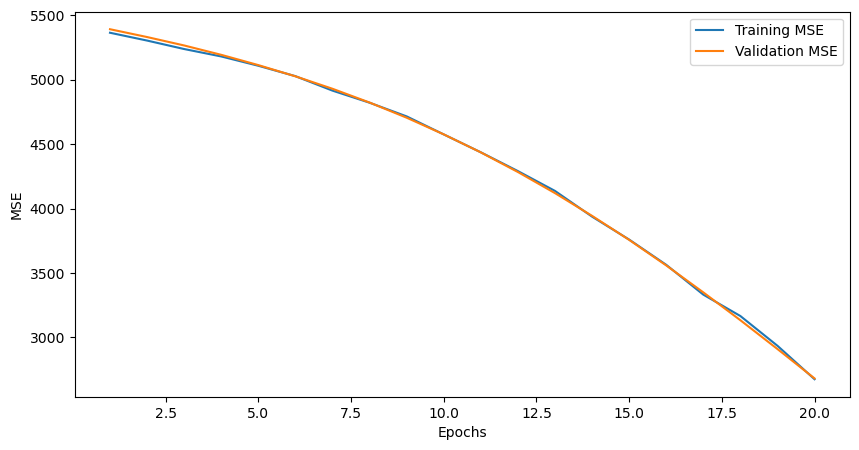

In [61]:
import matplotlib.pyplot as plt

train_mse = history.history['mse']
val_mse = history.history['val_mse']
epochs = range(1, len(train_mse)+1)

plt.figure(figsize=(10,5))
plt.plot(epochs, train_mse, label='Training MSE')
plt.plot(epochs, val_mse, label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

## 3-14 | 최종 모델 선택 및 결론 도출

### 【 문제 】

- linreg_model, xgb_model, dl_model의 MAE를 비교하세요.
- 가장 낮은 MAE를 보인 모델명을 답안14에 문자열로 저장하세요.
- 성능이 비슷하더라도 해석 가능성, 학습 시간, 배포 용이성 관점에서 실무 권장을 주석으로 작성하세요.

In [66]:
y_pred_dl = dl_model.predict(X_valid_scaled).flatten()
mae_dl = mean_absolute_error(y_valid, y_pred_dl)

print(f'Linear Regressor : {mae_lin}')
print(f'XGBoost Regressor : {mae_xgb}')
print(f'DeepLearing Model : {mae_dl}')

min_mae = min(mae_lin, mae_xgb, mae_dl)

if min_mae == mae_lin:
    답안14 = 'Linear Regressor'
elif min_mae == mae_xgb :
    답안14 = 'XGB Regressor'
else:
    답안14 = 'Deep Learning Model'

print(f'최종 답안 : {답안14}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Linear Regressor : 8.19463806767143
XGBoost Regressor : 7.315491676330566
DeepLearing Model : 50.49315643310547
최종 답안 : XGB Regressor
